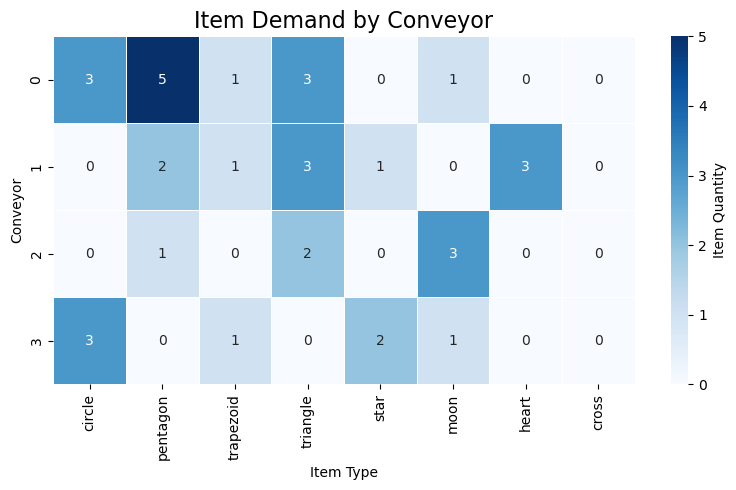

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../outputs/optimized_sorter_input.csv")

df = df.set_index("conv_num")

#fix the 'cirle' -> 'circle' typo in the .csv file
df = df.rename(columns={"cirle": "circle"})

plt.figure(figsize=(8,5))

sns.heatmap(
    df,
    annot=True,
    cmap="Blues",
    linewidths=0.5,
    cbar_kws={"label": "Item Quantity"}
)

plt.title("Item Demand by Conveyor", fontsize=16)
plt.xlabel("Item Type")
plt.ylabel("Conveyor")

plt.tight_layout()
plt.show()

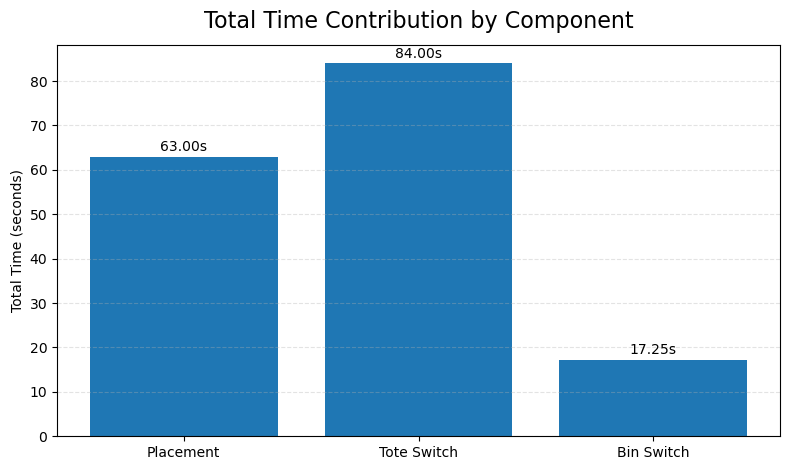

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../outputs/optimized_pick_plan.csv")

placement_time = 1.75 * len(df)
tote_switch_time = 4.0 * df["switched_tote"].sum()
bin_switch_time = 0.75 * df["switched_bin"].sum()

components = ["Placement", "Tote Switch", "Bin Switch"]
values = [placement_time, tote_switch_time, bin_switch_time]

plt.figure(figsize=(8, 4.8))
bars = plt.bar(components, values)

plt.title("Total Time Contribution by Component", fontsize=16, pad=12)
plt.ylabel("Total Time (seconds)")
plt.grid(axis="y", linestyle="--", alpha=0.35)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.2f}s",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

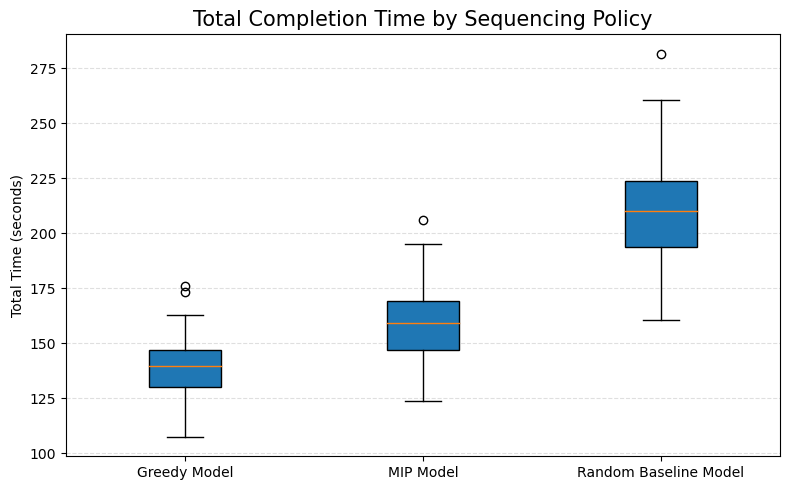

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../outputs/validation_runs.csv")

greedy_times = df[df["policy"] == "greedy"]["total_time"]
beam_times   = df[df["policy"] == "beam"]["total_time"]
random_times = df[df["policy"] == "random"]["total_time"]

plt.figure(figsize=(8,5))

plt.boxplot(
    [greedy_times, beam_times, random_times],
    labels=["Greedy Model", "MIP Model", "Random Baseline Model"],
    patch_artist=True
)

plt.title("Total Completion Time by Sequencing Policy", fontsize=15)
plt.ylabel("Total Time (seconds)")
plt.grid(axis='y', linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

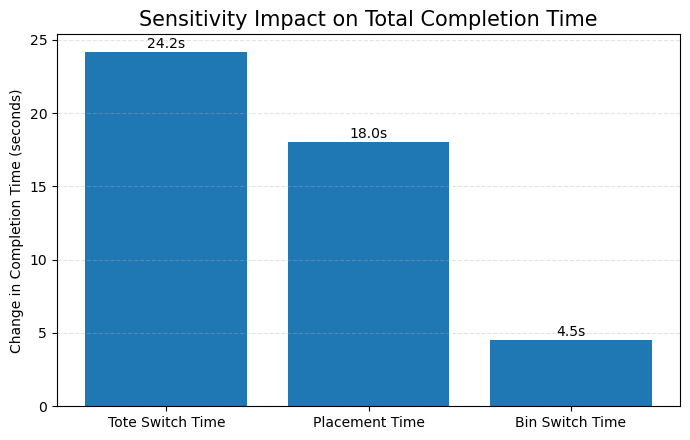

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../outputs/sensitivity_results.csv")

df = df[df["policy"] == "greedy"]

impact_tote = df.groupby("tote_switch_time")["total_time"].mean().max() - \
              df.groupby("tote_switch_time")["total_time"].mean().min()

impact_bin = df.groupby("bin_switch_time")["total_time"].mean().max() - \
             df.groupby("bin_switch_time")["total_time"].mean().min()

impact_place = df.groupby("place_time")["total_time"].mean().max() - \
               df.groupby("place_time")["total_time"].mean().min()

labels = ["Tote Switch Time", "Placement Time", "Bin Switch Time"]
values = [impact_tote, impact_place, impact_bin]

plt.figure(figsize=(7,4.5))

bars = plt.bar(labels, values)

plt.title("Sensitivity Impact on Total Completion Time", fontsize=15)
plt.ylabel("Change in Completion Time (seconds)")
plt.grid(axis="y", linestyle="--", alpha=0.35)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f"{height:.1f}s",
        ha="center"
    )

plt.tight_layout()
plt.show()